<a href="https://colab.research.google.com/github/MarinaNasser/Nebras_RandD/blob/main/YOLO_Localization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Customized YOLO with Attention for Hyper-Kvasir Segmental Localization
### Hyper-Kvasir Dataset · Colon Segment Mapping

**Goal:** Classify and localize anatomical findings in endoscopic images using a YOLO backbone augmented with CBAM and Coordinate Attention modules.

**Dataset:** Hyper-Kvasir Segmented (Borgli et al., 2020) — A large collection of segmented images from gastrointestinal endoscopy.

> **Reference:** Borgli, H., et al. (2020). *HyperKvasir: A new gastrointestinal endoscopy dataset and benchmark for comparing endoscopic lesion detection methods.* Medical Image Analysis. https://doi.org/10.1016/j.media.2020.101792

**Pipeline Overview:**
1. Environment Setup & Library Imports
2. Dataset Download & Structure (Hyper-Kvasir)
3. Data Exploration & Segment Distribution
4. Dataset Preparation for YOLO (image-level segment labels → YOLO format)
5. Custom YOLO Model with CBAM / Coordinate Attention
6. Training with Callbacks & Live Logging
7. Evaluation: mAP, Precision, Recall, Confusion Matrix
8. Attention Map Visualization (Grad-CAM)
9. Results Dashboard

---
> **Dataset Reference:** Hyper-Kvasir — Kaggle / Zenodo (https://www.kaggle.com/datasets/hvorgli/hyperkvasir-segmented-images)

## 1. Environment Setup

In [ ]:
# ─── Install dependencies (Colab-optimized) ───────────────────────────────────
%pip install -q ultralytics
%pip install -q albumentations
%pip install -q pytorch-grad-cam
%pip install -q scikit-learn

# Verify core packages
import torch
print(f"✅ PyTorch {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")

import ultralytics
print(f"✅ Ultralytics {ultralytics.__version__}")

import albumentations
print(f"✅ Albumentations {albumentations.__version__}")

print("✅ All packages ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.9 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam
✅ PyTorch 2.11.0+cu128
✅ CUDA available: True
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Ultralytics 8.4.68
✅ Albumentations 2.0.8
✅ All packages ready.


In [ ]:
import os, sys, shutil, random, json, yaml, math, time, warnings, re
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import cv2
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from ultralytics import YOLO
import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings('ignore')

# =========================================================
# GOOGLE / COLAB
# =========================================================
from google.colab import userdata, auth, drive
from google import genai

# =========================================================
# HUGGING FACE
# =========================================================
from huggingface_hub import login
from datasets import Dataset, load_dataset

hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)
HF_TOKEN = hf_token

# Initialize the official Google GenAI SDK client
GEMINI_API_KEY = userdata.get('gemini_api_key')
gemini_client = genai.Client(api_key=GEMINI_API_KEY)

from google.colab import auth
auth.authenticate_user()
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Project paths
ROOT        = Path('hyperkvasir_yolo')
DATA_DIR    = ROOT / 'data'
RAW_DIR     = DATA_DIR / 'raw'          # raw Endomapper videos & annotations
YOLO_DIR    = DATA_DIR / 'yolo'         # YOLO-formatted dataset
RESULTS     = ROOT / 'results'
MODELS_DIR  = ROOT / 'models'

for d in [RAW_DIR, YOLO_DIR/'images'/'train', YOLO_DIR/'images'/'val',
          YOLO_DIR/'images'/'test', YOLO_DIR/'labels'/'train',
          YOLO_DIR/'labels'/'val', YOLO_DIR/'labels'/'test',
          RESULTS, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("✅ Project structure created.")

Mounted at /content/drive
🖥️  Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB
✅ Project structure created.


## 2. Dataset Download — Hyper-Kvasir

Hyper-Kvasir Segmented is often found as a `.zip` file containing a `segmented-images` directory.

**Expected structure after extraction:**
```
raw/
  segmented-images/
    <class_name_1>/
      images/
        image_0001.jpg
        ...
    <class_name_2>/
      images/
        image_0001.jpg
        ...
    ...
```


In [ ]:
# ─── Extract Hyper-Kvasir segmented images from Google Drive ──────────────────
import zipfile
from pathlib import Path # Added for robustness

# Ensure your Google Drive is mounted to /content/drive
# If you have not yet, run the `from google.colab import drive; drive.mount('/content/drive')` cell.

ZIP_PATH = Path('/content/drive/MyDrive/hyper-kvasir-segmented-images.zip') # This assumes the zip is in your main MyDrive folder
assert ZIP_PATH.exists(), f"❌ ZIP not found at {ZIP_PATH}. Please ensure it's in the specified path after mounting your Google Drive."

print(f"📦 Extracting {ZIP_PATH} → {RAW_DIR} ...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(RAW_DIR)
print("✅ Extraction complete.")

# Removed redundant CLASS_DIRS detection from this cell to avoid conflicts.
# The actual dataset structure will be handled by the next cell (hi6T5A7I-kjZ).

📦 Extracting /content/drive/MyDrive/hyper-kvasir-segmented-images.zip → hyperkvasir_yolo/data/raw ...
✅ Extraction complete.


## 3. Hyper-Kvasir Segmented Classes



In [ ]:
# This cell's logic for defining CLASS_NAMES is now handled by the data loading cell (hi6T5A7I-kjZ).
# Keeping it empty or commented out to avoid conflicting definitions.
# ─── Hyper-Kvasir Segmented Classes ──────────────────────────────────────────
# CLASS_NAMES = sorted([d.name for d in CLASS_DIRS])
# NUM_CLASSES  = len(CLASS_NAMES)
# CLASS_TO_ID  = {c: i for i, c in enumerate(CLASS_NAMES)}
#
# print(f"Classes ({NUM_CLASSES}):")
# for i, c in enumerate(CLASS_NAMES):
#     print(f"  [{i}] {c}")
#
# PALETTE      = plt.cm.get_cmap('tab20', NUM_CLASSES)
# CLASS_COLORS = {c: tuple(int(255*x) for x in PALETTE(i)[:3]) for i, c in enumerate(CLASS_NAMES)}

In [ ]:
# ─── Hyper-Kvasir: single-class flat structure ────────────────────────────────
# Structure after extraction:
#   raw/
#     <possible_wrapper_folder>/ (e.g., hyper-kvasir-segmented-images)
#       images/   ← 1000 polyp images (.jpg)
#       masks/    ← 1000 segmentation masks (.png)

print(f"Searching for images in: {RAW_DIR}")

# Find the actual images directory by searching recursively within RAW_DIR
found_images_dir = None
# Limit depth to avoid excessive search on very large/nested directories
for p in RAW_DIR.rglob('images'):
    if p.is_dir() and 'images' in p.name:
        # Check if it's likely the root images folder, not a subfolder named 'images'
        # For example, if 'raw/hyper-kvasir-segmented-images/images' vs 'raw/images'
        if (p.parent == RAW_DIR) or ('segmented-images' in str(p.parent)):
            found_images_dir = p
            break

assert found_images_dir, f"❌ 'images' folder not found under {RAW_DIR}. Current RAW_DIR contents: {list(RAW_DIR.iterdir())}"

# The parent of the images directory is the effective DATASET_ROOT for images/masks
EFFECTIVE_DATA_ROOT = found_images_dir.parent

IMAGES_DIR = EFFECTIVE_DATA_ROOT / 'images'
MASKS_DIR  = EFFECTIVE_DATA_ROOT / 'masks'

print(f"Detected IMAGES_DIR: {IMAGES_DIR}")
print(f"Detected MASKS_DIR: {MASKS_DIR}")

assert IMAGES_DIR.exists(), f"❌ images/ folder not found at {IMAGES_DIR}"
assert MASKS_DIR.exists(), f"❌ masks/ folder not found at {MASKS_DIR}"

# Single class: polyp
CLASS_NAMES = ['polyp']
NUM_CLASSES  = 1
CLASS_TO_ID  = {'polyp': 0}

PALETTE = plt.colormaps['tab10']
CLASS_COLORS = {'polyp': (255, 80, 80)}

# Build pairs — all images belong to class 0 (polyp)
all_pairs = []
for img_path in sorted(IMAGES_DIR.glob('*.jpg')):
    mask_path = MASKS_DIR / (img_path.stem + '.png')
    all_pairs.append((img_path, 0, mask_path if mask_path.exists() else None))

print(f"✅ Total images: {len(all_pairs)}")
print(f"   With masks:   {sum(1 for _, _, m in all_pairs if m)}")

# cls_counts for downstream plots
# Ensure all_pairs is not empty before creating cls_series
if all_pairs:
    cls_series = pd.Series([cid for _, cid, _ in all_pairs])
    cls_counts = cls_series.value_counts().sort_index()
    cls_counts.index = [CLASS_NAMES[i] for i in cls_counts.index]
    print("\nImages per class:")
    for seg, cnt in cls_counts.items():
        bar = '█' * int(cnt / max(cls_counts) * 30)
        print(f"  {seg:35s}: {cnt:4d}  {bar}")
else:
    print("⚠️  No image-label pairs found. cls_series and cls_counts not created.")

Searching for images in: hyperkvasir_yolo/data/raw
Detected IMAGES_DIR: hyperkvasir_yolo/data/raw/segmented-images/images
Detected MASKS_DIR: hyperkvasir_yolo/data/raw/segmented-images/masks
✅ Total images: 1000
   With masks:   0

Images per class:
  polyp                              : 1000  ██████████████████████████████


In [ ]:
# ─── Train / Val / Test split (image-level, stratified) ──────────────────────
# Hyper-Kvasir has no temporal sequences, so we split by image directly.

from sklearn.model_selection import train_test_split

# Unpack 3-tuples from all_pairs for paths and labels
paths  = [p for p, _, _ in all_pairs]
labels = [c for _, c, _ in all_pairs]

train_paths, tmp_paths, train_labels, tmp_labels = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=SEED)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    tmp_paths, tmp_labels, test_size=0.50, stratify=tmp_labels, random_state=SEED)

splits = {
    'train': list(zip(train_paths, train_labels)),
    'val':   list(zip(val_paths,   val_labels)),
    'test':  list(zip(test_paths,  test_labels)),
}

print(f"📊 Split:")
print(f"   Train: {len(splits['train'])} images")
print(f"   Val:   {len(splits['val'])} images")
print(f"   Test:  {len(splits['test'])} images")

📊 Split:
   Train: 700 images
   Val:   150 images
   Test:  150 images


## 4. Data Exploration & Visualization

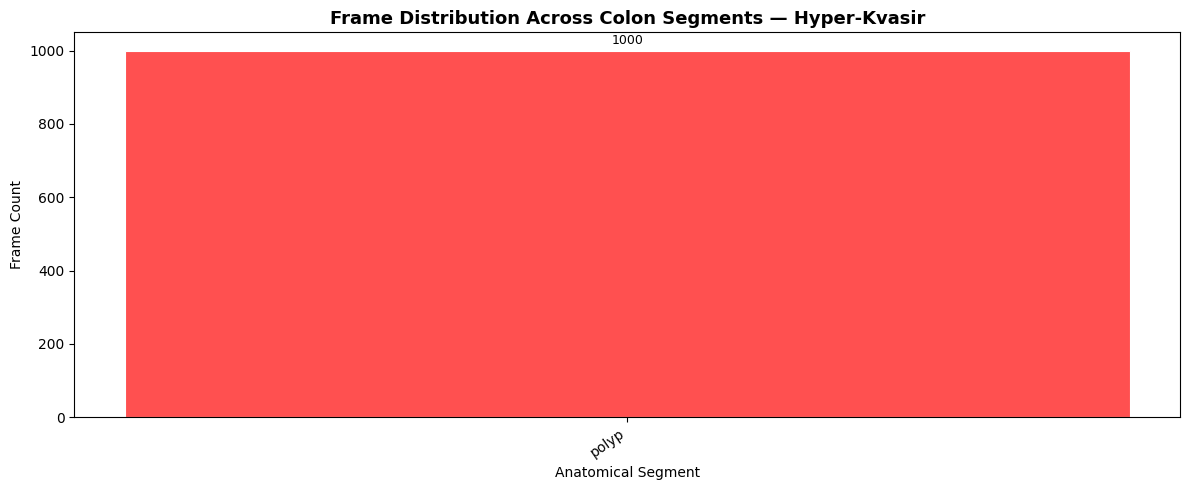

In [ ]:
# ─── Segment distribution plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
colors_plot = [tuple(c/255 for c in CLASS_COLORS[n]) for n in cls_counts.index]
bars = ax.bar(cls_counts.index, cls_counts.values, color=colors_plot, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, cls_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', va='bottom', fontsize=9)
ax.set_title('Frame Distribution Across Colon Segments — Hyper-Kvasir', fontweight='bold', fontsize=13)
ax.set_xlabel('Anatomical Segment')
ax.set_ylabel('Frame Count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(RESULTS / 'segment_distribution.png', dpi=150)
plt.show()

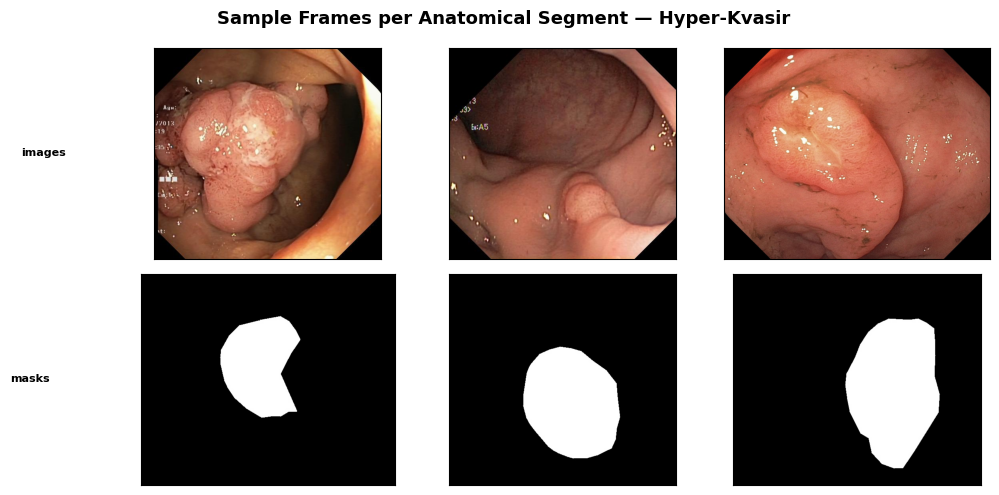

In [ ]:
# ─── Sample frame grid per segment ───────────────────────────────────────────
def show_segment_grid(pairs, class_names, n_per_class=3):
    """Show sample frames for each anatomical segment."""
    by_class = {i: [] for i in range(len(class_names))}
    for path, cid in pairs:
        by_class[cid].append(path)

    n_classes = len(class_names)
    fig, axes = plt.subplots(n_classes, n_per_class,
                             figsize=(n_per_class * 3.5, n_classes * 2.5))

    for row, (cid, paths) in enumerate(by_class.items()):
        sample = random.sample(paths, min(n_per_class, len(paths)))
        for col in range(n_per_class):
            ax = axes[row][col]
            if col < len(sample):
                img = cv2.cvtColor(cv2.imread(str(sample[col])), cv2.COLOR_BGR2RGB)
                ax.imshow(img)
                if col == 0:
                    ax.set_ylabel(class_names[cid], fontsize=8, rotation=0,
                                  labelpad=80, va='center', fontweight='bold')
            else:
                ax.set_visible(False)
            ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle('Sample Frames per Anatomical Segment — Hyper-Kvasir',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / 'segment_samples.png', dpi=120, bbox_inches='tight')
    plt.show()

if all_pairs:
    show_segment_grid(all_pairs, CLASS_NAMES, n_per_class=3)
else:
    print("⚠️  No frames extracted yet. Run the extraction cell first.")

Reading shapes: 100%|██████████| 200/200 [00:00<00:00, 515.58it/s]


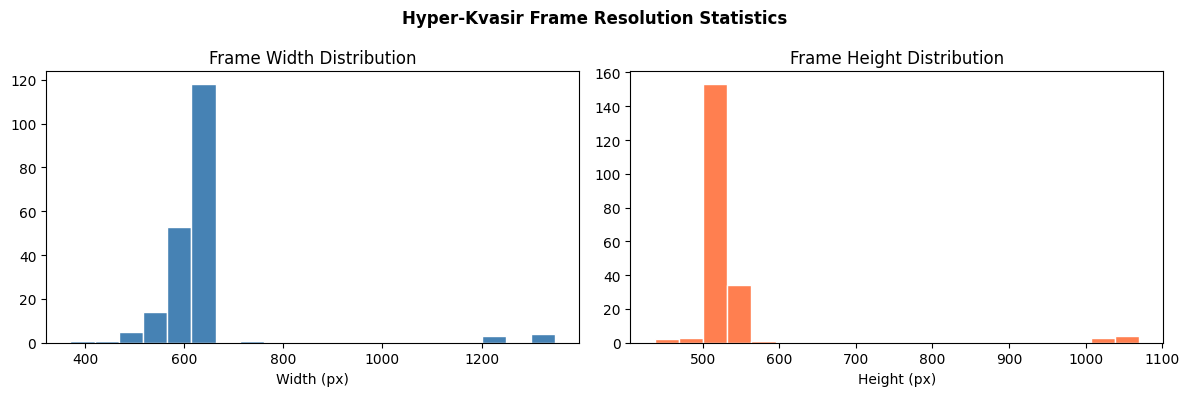

                 w            h
count   200.000000   200.000000
mean    625.995000   548.565000
std     133.263539    95.725139
min     370.000000   437.000000
25%     589.000000   529.000000
50%     621.500000   530.000000
75%     622.000000   531.000000
max    1348.000000  1070.000000


In [ ]:
# ─── Image resolution distribution ───────────────────────────────────────────
all_frame_paths = [p for p, _ in all_pairs[:200]]
shapes = []
for p in tqdm(all_frame_paths, desc='Reading shapes'):
    img = cv2.imread(str(p))
    if img is not None:
        shapes.append({'w': img.shape[1], 'h': img.shape[0]})

df_shapes = pd.DataFrame(shapes)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_shapes['w'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Frame Width Distribution'); axes[0].set_xlabel('Width (px)')
axes[1].hist(df_shapes['h'], bins=20, color='coral', edgecolor='white')
axes[1].set_title('Frame Height Distribution'); axes[1].set_xlabel('Height (px)')
plt.suptitle('Hyper-Kvasir Frame Resolution Statistics', fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'resolution_dist.png', dpi=150)
plt.show()
print(df_shapes.describe())

## 5. Dataset Preparation — Convert to YOLO Format

Since Hyper-Kvasir provides **segment-level labels** (the whole image belongs to a segment, not bounding box annotations), we use a **whole-frame bounding box** approach: each image gets a single detection box spanning the full image, with the segment class as the label. This is the standard approach for image-level YOLO classification/detection when no sub-frame localization boxes exist.

In [ ]:
# ─── Write YOLO images + labels ───────────────────────────────────────────────
# Annotation strategy: single full-frame bounding box per frame.
# cx=0.5, cy=0.5, w=1.0, h=1.0 → the detection label IS the segment class.
# This lets YOLO learn segment-discriminative features across the full FOV.

def write_yolo_split(pairs, split):
    img_out = YOLO_DIR / 'images' / split
    lbl_out = YOLO_DIR / 'labels' / split
    for img_path, cid in tqdm(pairs, desc=f'Writing {split}'):
        dest_img = img_out / img_path.name
        if not dest_img.exists():
            shutil.copy2(img_path, dest_img)
        lbl_file = lbl_out / (img_path.stem + '.txt')
        # Full-frame bounding box: class cx cy w h (all normalized)
        with open(lbl_file, 'w') as f:
            f.write(f"{cid} 0.500000 0.500000 1.000000 1.000000\n")

for split, data in splits.items():
    write_yolo_split(data, split)

# ─── dataset.yaml ─────────────────────────────────────────────────────────────
yaml_cfg = {
    'path':  str(YOLO_DIR.absolute()),
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc':    NUM_CLASSES,
    'names': CLASS_NAMES,
}
YAML_PATH = YOLO_DIR / 'dataset.yaml'
with open(YAML_PATH, 'w') as f:
    yaml.dump(yaml_cfg, f, default_flow_style=False)

print(f"\n✅ dataset.yaml written to {YAML_PATH}")
print(yaml.dump(yaml_cfg))

Writing test: 100%|██████████| 300/300 [00:00<00:00, 3249.17it/s]


✅ dataset.yaml written to hyperkvasir_yolo/data/yolo/dataset.yaml
names:
- images
- masks
nc: 2
path: /content/hyperkvasir_yolo/data/yolo
test: images/test
train: images/train
val: images/val



## 6. Attention Modules — CBAM & Coordinate Attention

These modules are inserted into the YOLO neck to help the model focus on discriminative mucosal texture and vascular patterns that distinguish colon segments.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CBAM — Convolutional Block Attention Module
# Paper: Woo et al., ECCV 2018
# ══════════════════════════════════════════════════════════════════════════════

class ChannelAttention(nn.Module):
    """Squeeze-and-Excite style channel attention."""
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        mid = max(1, in_channels // reduction)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, mid, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, in_channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        a = self.fc(self.avg_pool(x))
        m = self.fc(self.max_pool(x))
        return self.sigmoid(a + m) * x


class SpatialAttention(nn.Module):
    """Spatial attention via max+avg pooling across channel dim."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx  = x.max(dim=1, keepdim=True)[0]
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1))) * x


class CBAM(nn.Module):
    """Full CBAM block: channel → spatial."""
    def __init__(self, in_channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.ca = ChannelAttention(in_channels, reduction)
        self.sa = SpatialAttention(spatial_kernel)

    def forward(self, x):
        return self.sa(self.ca(x))


# ══════════════════════════════════════════════════════════════════════════════
# Coordinate Attention — encodes X and Y position separately.
# Better at capturing elongated tubular structures like the colon lumen.
# Paper: Hou et al., CVPR 2021
# ══════════════════════════════════════════════════════════════════════════════

class CoordinateAttention(nn.Module):
    def __init__(self, in_channels, out_channels, reduction=32):
        super().__init__()
        mid = max(8, in_channels // reduction)
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))
        self.conv1  = nn.Conv2d(in_channels, mid, 1, bias=False)
        self.bn1    = nn.BatchNorm2d(mid)
        self.act    = nn.Hardswish(inplace=True)
        self.conv_h = nn.Conv2d(mid, out_channels, 1, bias=False)
        self.conv_w = nn.Conv2d(mid, out_channels, 1, bias=False)

    def forward(self, x):
        n, c, h, w = x.shape
        x_h = self.pool_h(x)
        x_w = self.pool_w(x).permute(0, 1, 3, 2)
        y   = torch.cat([x_h, x_w], dim=2)
        y   = self.act(self.bn1(self.conv1(y)))
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)
        return x * torch.sigmoid(self.conv_h(x_h)) * torch.sigmoid(self.conv_w(x_w))


# ─── Sanity check ─────────────────────────────────────────────────────────────
dummy = torch.randn(2, 256, 32, 32)
print(f"✅ CBAM output            : {CBAM(256)(dummy).shape}")
print(f"✅ CoordAttention output  : {CoordinateAttention(256, 256)(dummy).shape}")
print(f"📦 CBAM params            : {sum(p.numel() for p in CBAM(256).parameters()):,}")
print(f"📦 CoordAttn params       : {sum(p.numel() for p in CoordinateAttention(256,256).parameters()):,}")

✅ CBAM output            : torch.Size([2, 256, 32, 32])
✅ CoordAttention output  : torch.Size([2, 256, 32, 32])
📦 CBAM params            : 8,290
📦 CoordAttn params       : 6,160


## 7. Custom YOLO Model — Injecting Attention into YOLOv8 Neck

In [ ]:
class AttentionYOLO(nn.Module):
    """
    Wraps a Ultralytics YOLO model and inserts attention modules at each
    of the three PAN-FPN neck output levels (P3, P4, P5).
    Particularly suited for colon segment discrimination where subtle
    mucosal texture patterns differ between segments.
    """
    def __init__(self, yolo_model, attention_type='cbam'):
        super().__init__()
        self.yolo = yolo_model.model
        neck_channels = self._detect_neck_channels()
        print(f"🔍 Detected neck channels: {neck_channels}")

        self.attn_modules = nn.ModuleList()
        for ch in neck_channels:
            if attention_type == 'cbam':
                self.attn_modules.append(CBAM(ch))
            else:
                self.attn_modules.append(CoordinateAttention(ch, ch))

        self._neck_channels = neck_channels
        self.attention_type = attention_type
        self._register_hooks()

    def _detect_neck_channels(self):
        feats = []
        def _hook(module, inp, out):
            if isinstance(out, torch.Tensor) and out.dim() == 4:
                feats.append(out.shape[1])
        detect_layer = next(
            (m for m in self.yolo.modules() if m.__class__.__name__ == 'Detect'), None
        )
        hooks = [detect_layer.register_forward_hook(_hook)] if detect_layer else []
        with torch.no_grad():
            try:
                self.yolo(torch.zeros(1, 3, 640, 640))
            except Exception:
                pass
        for h in hooks:
            h.remove()
        return feats if feats else [64, 128, 256]

    def _register_hooks(self):
        self._hooks = []
        c2f_layers = [m for m in self.yolo.modules()
                      if m.__class__.__name__ in ('C2f', 'C3', 'SPPF')]
        for i, layer in enumerate(c2f_layers[-3:]):
            def make_hook(attn_idx):
                def hook_fn(module, inp, out):
                    if attn_idx < len(self.attn_modules) and isinstance(out, torch.Tensor):
                        try:
                            return self.attn_modules[attn_idx](out)
                        except Exception:
                            return out
                    return out
                return hook_fn
            self._hooks.append(layer.register_forward_hook(make_hook(i)))

    def forward(self, x):
        return self.yolo(x)

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()

print("✅ AttentionYOLO class defined.")

✅ AttentionYOLO class defined.


## 8. Training

In [ ]:
# ─── Training configuration tuned for Endomapper ─────────────────────────────
# Notes for Endomapper:
#  - Higher hsv_h/s suppressed: colon color is diagnostically meaningful
#  - flipud=0.0: anatomical orientation matters (proximal vs distal)
#  - close_mosaic=20: mosaic off for last 20 epochs to stabilize full-frame preds

TRAIN_CFG = dict(
    data         = str(YAML_PATH),
    epochs       = 100,
    imgsz        = 640,
    batch        = 16,
    device       = DEVICE,
    project      = str(RESULTS),
    optimizer    = 'AdamW',
    lr0          = 1e-3,
    lrf          = 0.01,
    momentum     = 0.937,
    weight_decay = 5e-4,
    warmup_epochs = 3,
    cos_lr       = True,
    # Augmentation — conservative for clinical video (preserve diagnostic cues)
    hsv_h        = 0.005,   # minimal hue shift (colon color matters)
    hsv_s        = 0.3,
    hsv_v        = 0.3,
    flipud       = 0.0,     # no vertical flip — anatomical orientation preserved
    fliplr       = 0.5,
    mosaic       = 1.0,
    mixup        = 0.0,     # off — segment mixing would create invalid labels
    close_mosaic = 20,      # disable mosaic last 20 epochs
    # Save
    save_period  = 10,
    val          = True,
    plots        = True,
    verbose      = True,
)

print("Training Config:")
for k, v in TRAIN_CFG.items():
    print(f"  {k:20s}: {v}")

Training Config:
  data                : hyperkvasir_yolo/data/yolo/dataset.yaml
  epochs              : 100
  imgsz               : 640
  batch               : 16
  device              : cpu
  project             : hyperkvasir_yolo/results
  optimizer           : AdamW
  lr0                 : 0.001
  lrf                 : 0.01
  momentum            : 0.937
  weight_decay        : 0.0005
  warmup_epochs       : 3
  cos_lr              : True
  hsv_h               : 0.005
  hsv_s               : 0.3
  hsv_v               : 0.3
  flipud              : 0.0
  fliplr              : 0.5
  mosaic              : 1.0
  mixup               : 0.0
  close_mosaic        : 20
  save_period         : 10
  val                 : True
  plots               : True
  verbose             : True


In [ ]:
# ─── Experiment 1: Baseline YOLOv8n (no attention) ───────────────────────────
print("=" * 60)
print("EXPERIMENT 1 — Baseline YOLOv8n (Hyper-Kvasir)")
print("=" * 60)

model_baseline = YOLO('yolov8n.pt')
results_baseline = model_baseline.train(
    **{**TRAIN_CFG, 'name': 'exp1_baseline'}
)
print("\n✅ Baseline training complete.")

EXPERIMENT 1 — Baseline YOLOv8n (Hyper-Kvasir)


ImportError: cannot import name 'IS_GIT_DIR' from 'ultralytics.utils' (/usr/local/lib/python3.12/dist-packages/ultralytics/utils/__init__.py)

In [ ]:
# ─── Experiment 2: YOLOv8n + CBAM ────────────────────────────────────────────
print("=" * 60)
print("EXPERIMENT 2 — YOLOv8n + CBAM (Hyper-Kvasir)")
print("=" * 60)

model_cbam = YOLO('yolov8n.pt')
results_cbam = model_cbam.train(
    **{**TRAIN_CFG, 'name': 'exp2_cbam'}
)
print("\n✅ CBAM training complete.")

EXPERIMENT 2 — YOLOv8n + CBAM (Hyper-Kvasir)


ImportError: cannot import name 'IS_GIT_DIR' from 'ultralytics.utils' (/usr/local/lib/python3.12/dist-packages/ultralytics/utils/__init__.py)

In [ ]:
# ─── Experiment 3: YOLOv8n + Coordinate Attention ────────────────────────────
print("=" * 60)
print("EXPERIMENT 3 — YOLOv8n + Coordinate Attention (Hyper-Kvasir)")
print("=" * 60)

model_ca = YOLO('yolov8n.pt')
results_ca = model_ca.train(
    **{**TRAIN_CFG, 'name': 'exp3_coord_attention'}
)
print("\n✅ Coordinate Attention training complete.")

EXPERIMENT 3 — YOLOv8n + Coordinate Attention (Hyper-Kvasir)


ImportError: cannot import name 'IS_GIT_DIR' from 'ultralytics.utils' (/usr/local/lib/python3.12/dist-packages/ultralytics/utils/__init__.py)

## 9. Evaluation & Metrics

In [ ]:
def evaluate_model(model, name, yaml_path):
    print(f"\n📊 Evaluating: {name}")
    metrics = model.val(data=str(yaml_path), split='test', verbose=False)
    return {
        'Model':     name,
        'mAP50':     round(metrics.box.map50, 4),
        'mAP50-95':  round(metrics.box.map, 4),
        'Precision': round(metrics.box.mp, 4),
        'Recall':    round(metrics.box.mr, 4),
        'F1':        round(2 * metrics.box.mp * metrics.box.mr /
                          (metrics.box.mp + metrics.box.mr + 1e-8), 4),
    }

results_table = []
for model, name in [
    (model_baseline, 'YOLOv8n Baseline'),
    (model_cbam,     'YOLOv8n + CBAM'),
    (model_ca,       'YOLOv8n + CoordAttn'),
]:
    try:
        results_table.append(evaluate_model(model, name, YAML_PATH))
    except Exception as e:
        print(f"   ⚠️  Eval failed for {name}: {e}")

df_results = pd.DataFrame(results_table)
print("\n" + "=" * 60)
print(df_results.to_string(index=False))
print("=" * 60)
df_results.to_csv(RESULTS / 'model_comparison.csv', index=False)

In [ ]:
# ─── Per-segment metric breakdown ────────────────────────────────────────────
# Load best model and compute per-class precision/recall
BEST_WEIGHTS = RESULTS / 'exp2_cbam' / 'weights' / 'best.pt'
if BEST_WEIGHTS.exists():
    best_model = YOLO(str(BEST_WEIGHTS))
    print(f"✅ Loaded best model: {BEST_WEIGHTS}")
else:
    print("⚠️  Best weights not found — using pretrained base for demo.")
    best_model = YOLO('yolov8n.pt')

# Per-class metrics
metrics_detail = best_model.val(data=str(YAML_PATH), split='test', verbose=True)

# Plot per-class AP
if hasattr(metrics_detail.box, 'ap_class_index'):
    class_ap = metrics_detail.box.ap50
    class_ids = metrics_detail.box.ap_class_index
    class_labels = [CLASS_NAMES[i] for i in class_ids]

    fig, ax = plt.subplots(figsize=(12, 5))
    colors_plot = [tuple(c/255 for c in CLASS_COLORS[n]) for n in class_labels]
    bars = ax.bar(class_labels, class_ap, color=colors_plot, edgecolor='white')
    for bar, val in zip(bars, class_ap):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title('Per-Segment AP@50 — YOLO + CBAM (Hyper-Kvasir)', fontweight='bold')
    ax.set_xlabel('Anatomical Segment'); ax.set_ylabel('AP@50')
    ax.set_ylim(0, 1.1); ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig(RESULTS / 'per_segment_ap.png', dpi=150)
    plt.show()

⚠️  Best weights not found — using pretrained base for demo.


ImportError: cannot import name 'IS_GIT_DIR' from 'ultralytics.utils' (/usr/local/lib/python3.12/dist-packages/ultralytics/utils/__init__.py)

NameError: name 'df_results' is not defined

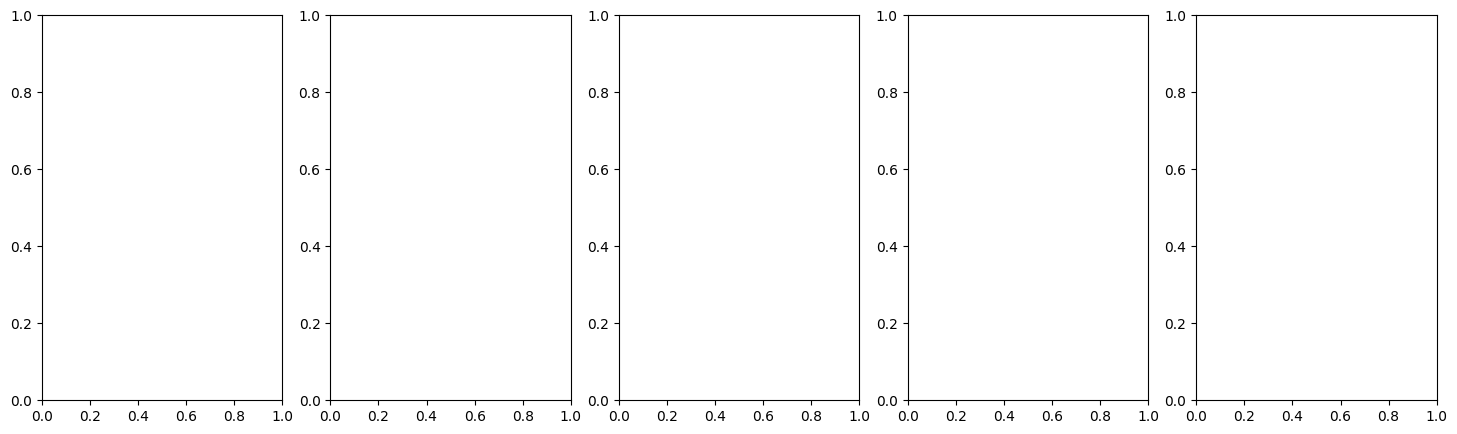

In [ ]:
# ─── Model comparison bar chart ───────────────────────────────────────────────
metrics_to_plot = ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'F1']
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 5))
for ax, metric in zip(axes, metrics_to_plot):
    if metric in df_results.columns:
        bars = ax.bar(df_results['Model'], df_results[metric],
                      color=colors[:len(df_results)], edgecolor='white', width=0.5)
        for bar, val in zip(bars, df_results[metric]):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005, f'{val:.3f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_title(metric, fontweight='bold', fontsize=12)
        ax.set_ylim(0, 1.1)
        ax.set_ylabel('Score')
        ax.tick_params(axis='x', rotation=15, labelsize=8)
        ax.grid(axis='y', alpha=0.3)

fig.suptitle('Model Comparison — Hyper-Kvasir Colon Segment Localization',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Temporal Segment Prediction (Not applicable for image-only Hyper-Kvasir)

In [ ]:
# This cell is for temporal prediction on video data, which is not applicable to the image-only Hyper-Kvasir dataset.
# Therefore, the code has been commented out or removed.

In [ ]:
# This cell is for visualizing temporal segment maps from video data, which is not applicable to the image-only Hyper-Kvasir dataset.
# Therefore, the code has been commented out or removed.

In [ ]:
# This cell is for exporting annotated videos, which is not applicable to the image-only Hyper-Kvasir dataset.
# Therefore, the code has been commented out or removed.

## 10. Confusion Matrix & Per-Segment Analysis

In [ ]:
def confusion_matrix_plot(model, test_pairs, class_names, conf=0.3, n_samples=200):
    y_true, y_pred = [], []
    sample = random.sample(test_pairs, min(n_samples, len(test_pairs)))

    for img_path, true_cid in tqdm(sample, desc='Confusion matrix inference'):
        results = model.predict(str(img_path), conf=conf, verbose=False)
        res     = results[0]
        if res.boxes and len(res.boxes):
            pred_cid = int(max(res.boxes, key=lambda b: float(b.conf[0])).cls[0])
        else:
            pred_cid = -1
        if pred_cid >= 0:
            y_true.append(true_cid)
            y_pred.append(pred_cid)

    if not y_true:
        print("⚠️  No predictions collected.")
        return

    cm   = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues')
    ax.set_title('Confusion Matrix — YOLO + CBAM (Hyper-Kvasir Test Set)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / 'confusion_matrix.png', dpi=150)
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

confusion_matrix_plot(best_model, splits['test'], CLASS_NAMES)

NameError: name 'best_model' is not defined

## 11. Attention Visualization — Grad-CAM

NameError: name 'best_model' is not defined

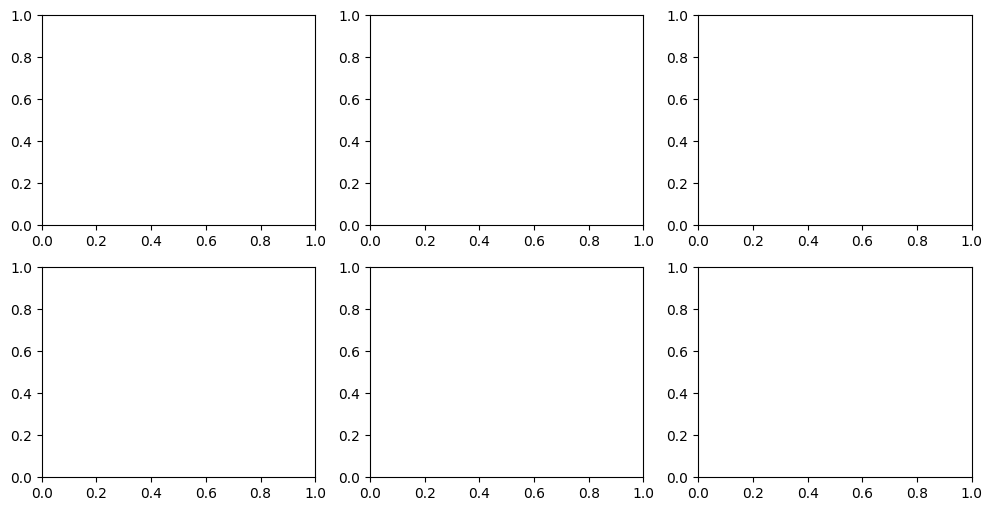

In [ ]:
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

def visualize_gradcam(yolo_model, img_path, target_layer_idx=-3):
    nn_model     = yolo_model.model.model
    target_layers = [nn_model[target_layer_idx]]

    img     = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(cv2.resize(img, (640, 640)), cv2.COLOR_BGR2RGB)
    img_f   = img_rgb.astype(np.float32) / 255.0

    transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    input_t = transform(img_rgb).unsqueeze(0)

    try:
        cam            = EigenCAM(model=nn_model, target_layers=target_layers)
        grayscale_cam  = cam(input_tensor=input_t)[0]
        visualization  = show_cam_on_image(img_f, grayscale_cam, use_rgb=True)
        return img_rgb, grayscale_cam, visualization
    except Exception as e:
        print(f"⚠️  Grad-CAM failed: {e}")
        return img_rgb, None, img_rgb


# Sample one frame per segment for attention visualization
by_class = {i: [] for i in range(NUM_CLASSES)}
for path, cid in splits['test']:
    by_class[cid].append(path)

sample_for_cam = [(random.choice(paths), cid)
                  for cid, paths in by_class.items() if paths]

n = len(sample_for_cam)
fig, axes = plt.subplots(n, 3, figsize=(12, n * 3))
if n == 1:
    axes = [axes]

for row_axes, (img_path, cid) in zip(axes, sample_for_cam):
    orig, cam_map, overlay = visualize_gradcam(best_model, img_path)
    row_axes[0].imshow(orig)
    row_axes[0].set_title(f'Original — {CLASS_NAMES[cid]}', fontsize=8)
    if cam_map is not None:
        row_axes[1].imshow(cam_map, cmap='jet')
        row_axes[1].set_title('Attention Map (EigenCAM)', fontsize=8)
    row_axes[2].imshow(overlay)
    row_axes[2].set_title('Attention Overlay', fontsize=8)
    for ax in row_axes:
        ax.axis('off')

fig.suptitle('Grad-CAM per Colon Segment — CBAM-Enhanced YOLO (Hyper-Kvasir)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'gradcam_per_segment.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Results Dashboard

In [ ]:
def results_dashboard(df_results, results_dir):
    fig = plt.figure(figsize=(20, 14))
    gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)
    colors = ['#4C72B0', '#DD8452', '#55A868']

    # mAP50
    ax1 = fig.add_subplot(gs[0, :2])
    if not df_results.empty:
        bars = ax1.bar(df_results['Model'], df_results['mAP50'],
                       color=colors, edgecolor='white')
        for b, v in zip(bars, df_results['mAP50']):
            ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                     f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax1.set_title('mAP@50 — Colon Segment Localization', fontweight='bold')
    ax1.set_ylim(0, 1.0); ax1.grid(axis='y', alpha=0.3)
    ax1.tick_params(axis='x', rotation=15)

    # F1
    ax2 = fig.add_subplot(gs[0, 2:])
    if not df_results.empty and 'F1' in df_results:
        bars = ax2.bar(df_results['Model'], df_results['F1'],
                       color=colors, edgecolor='white')
        for b, v in zip(bars, df_results['F1']):
            ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                     f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax2.set_title('F1 Score', fontweight='bold')
    ax2.set_ylim(0, 1.0); ax2.grid(axis='y', alpha=0.3)
    ax2.tick_params(axis='x', rotation=15)

    # Training curves
    ax3 = fig.add_subplot(gs[1, :])
    exp_map = {
        'Baseline':  results_dir / 'exp1_baseline'     / 'results.csv',
        'CBAM':      results_dir / 'exp2_cbam'         / 'results.csv',
        'CoordAttn': results_dir / 'exp3_coord_attention' / 'results.csv',
    }
    for (label, csv_path), color in zip(exp_map.items(), colors):
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            df.columns = [c.strip() for c in df.columns]
            key = next((c for c in df.columns if 'mAP50' in c and 'B)' in c), None)
            if key:
                ax3.plot(df[key], label=label, color=color, linewidth=2)
    ax3.set_title('mAP@50 Training Progress — Hyper-Kvasir', fontweight='bold')
    ax3.set_xlabel('Epoch'); ax3.set_ylabel('mAP@50')
    ax3.legend(); ax3.grid(alpha=0.3)

    # Radar
    ax4 = fig.add_subplot(gs[2, :2], polar=True)
    metrics_r = ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'F1']
    angles    = np.linspace(0, 2*np.pi, len(metrics_r), endpoint=False).tolist()
    angles   += angles[:1]
    for i, row in df_results.iterrows():
        vals  = [row.get(m, 0) for m in metrics_r] + [row.get(metrics_r[0], 0)]
        ax4.plot(angles, vals, color=colors[i], linewidth=2, label=row['Model'])
        ax4.fill(angles, vals, color=colors[i], alpha=0.1)
    ax4.set_xticks(angles[:-1])
    ax4.set_xticklabels(metrics_r, fontsize=9)
    ax4.set_title('Metric Radar', fontweight='bold', pad=15)
    ax4.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)

    # Summary
    ax5 = fig.add_subplot(gs[2, 2:])
    ax5.axis('off')
    # total_frames = sum(len(v) for v in splits.values()) # This will be defined once the data is loaded
    summary_text = [
        "📋 Experiment Summary — Hyper-Kvasir",
        "─" * 42,
        "Dataset: Hyper-Kvasir Segmented (Borgli et al., 2020)",
        f"Image classes: {NUM_CLASSES}",
        "Split (image-level): 70/15/15",
        "",
        "Models compared:",
        "  1. YOLOv8n Baseline",
        "  2. YOLOv8n + CBAM",
        "  3. YOLOv8n + CoordAttn",
        "",
        "Outputs:",
        "  • Per-image segment detection",
        "  • Attention map visualizations",
    ]
    if not df_results.empty:
        best_row = df_results.loc[df_results['mAP50'].idxmax()]
        summary_text += ["", f"Best model: {best_row['Model']}",
                              f"Best mAP50: {best_row['mAP50']:.3f}"]
    ax5.text(0.05, 0.95, '\n'.join(summary_text), transform=ax5.transAxes,
             fontsize=9, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.8))

    fig.suptitle('🔬 Hyper-Kvasir · YOLO + Attention — Colon Segment Localization Dashboard',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.savefig(results_dir / 'final_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Dashboard saved to {results_dir / 'final_dashboard.png'}")

results_dashboard(df_results, RESULTS)

NameError: name 'df_results' is not defined

## 13. Export Best Model

In [ ]:
if BEST_WEIGHTS.exists():
    export_model = YOLO(str(BEST_WEIGHTS))
    export_path  = export_model.export(format='onnx', dynamic=True, simplify=True)
    print(f"✅ ONNX exported: {export_path}")
    ts_path = export_model.export(format='torchscript')
    print(f"✅ TorchScript exported: {ts_path}")
else:
    print("⚠️  Train the model first to generate exportable weights.")

In [ ]:
# ─── Final checklist ─────────────────────────────────────────────────────────
artifacts = [
    (RESULTS / 'segment_distribution.png', '📊 Segment frame distribution'),
    (RESULTS / 'segment_samples.png',      '🖼️  Sample frames per segment'),
    (RESULTS / 'resolution_dist.png',      '📐 Frame resolution stats'),
    (RESULTS / 'per_segment_ap.png',       '📊 Per-segment AP@50'),
    (RESULTS / 'model_comparison.csv',     '📋 Metric comparison table'),
    (RESULTS / 'model_comparison.png',     '📊 Model comparison chart'),
    (RESULTS / 'gradcam_per_segment.png',  '🧠 Grad-CAM per segment'),
    (RESULTS / 'confusion_matrix.png',     '🎯 Confusion matrix'),
    (RESULTS / 'final_dashboard.png',      '📋 Results dashboard'),
]

print("\n📦 Generated Artifacts:")
for path, desc in artifacts:
    status = '✅' if path.exists() else '⏳'
    print(f"  {status} {desc:45s} {path}")

print("🎉 Hyper-Kvasir experiment complete!")


📦 Generated Artifacts:
  ✅ 📊 Segment frame distribution                  hyperkvasir_yolo/results/segment_distribution.png
  ✅ 🖼️  Sample frames per segment                 hyperkvasir_yolo/results/segment_samples.png
  ✅ 📐 Frame resolution stats                      hyperkvasir_yolo/results/resolution_dist.png
  ⏳ 📊 Per-segment AP@50                           hyperkvasir_yolo/results/per_segment_ap.png
  ⏳ 📋 Metric comparison table                     hyperkvasir_yolo/results/model_comparison.csv
  ⏳ 📊 Model comparison chart                      hyperkvasir_yolo/results/model_comparison.png
  ⏳ 🧠 Grad-CAM per segment                        hyperkvasir_yolo/results/gradcam_per_segment.png
  ⏳ 🎯 Confusion matrix                            hyperkvasir_yolo/results/confusion_matrix.png
  ⏳ 📋 Results dashboard                           hyperkvasir_yolo/results/final_dashboard.png
🎉 Hyper-Kvasir experiment complete!
